# Titanic Survival Prediction

Goal: predict survival on the Titanic using passenger attributes.
The notebook emphasizes title extraction, family-size features, cabin presence,
missing-value handling, categorical encoding, model evaluation, and feature-importance explanation.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

DATA_PATH = Path("titanic.csv")
ARTIFACTS_DIR = Path("artifacts")
MODEL_PATH = ARTIFACTS_DIR / "best_titanic_model.joblib"
TARGET = "Survived"
ARTIFACTS_DIR.mkdir(exist_ok=True)

## Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [4]:
print("Missing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nSurvival counts:")
print(df[TARGET].value_counts())

Missing values:
Cabin          327
Age             86
Fare             1
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

Survival counts:
Survived
0    266
1    152
Name: count, dtype: int64


## Feature Engineering

In [5]:
def extract_title(name):
    title = name.split(",")[1].split(".")[0].strip()
    title_map = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
        "Lady": "Rare",
        "Countess": "Rare",
        "Capt": "Rare",
        "Col": "Rare",
        "Don": "Rare",
        "Dr": "Rare",
        "Major": "Rare",
        "Rev": "Rare",
        "Sir": "Rare",
        "Jonkheer": "Rare",
        "Dona": "Rare",
    }
    return title_map.get(title, title)


def prepare_features(data):
    prepared = data.copy()
    prepared["Title"] = prepared["Name"].apply(extract_title)
    prepared["FamilySize"] = prepared["SibSp"] + prepared["Parch"] + 1
    prepared["IsAlone"] = (prepared["FamilySize"] == 1).astype(int)
    prepared["CabinPresent"] = prepared["Cabin"].notna().map({True: "Yes", False: "No"})
    return prepared


prepared = prepare_features(df)
prepared[["Name", "Title", "SibSp", "Parch", "FamilySize", "IsAlone", "Cabin", "CabinPresent"]].head()

,Name,Title,SibSp,Parch,FamilySize,IsAlone,Cabin,CabinPresent
0,"Kelly, Mr. James",Mr,0,0,1,1,NaN,No
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs,1,0,2,0,NaN,No
2,"Myles, Mr. Thomas Francis",Mr,0,0,1,1,NaN,No
3,"Wirz, Mr. Albert",Mr,0,0,1,1,NaN,No
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs,1,1,3,0,NaN,No


In [6]:
prepared["Title"].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

## EDA

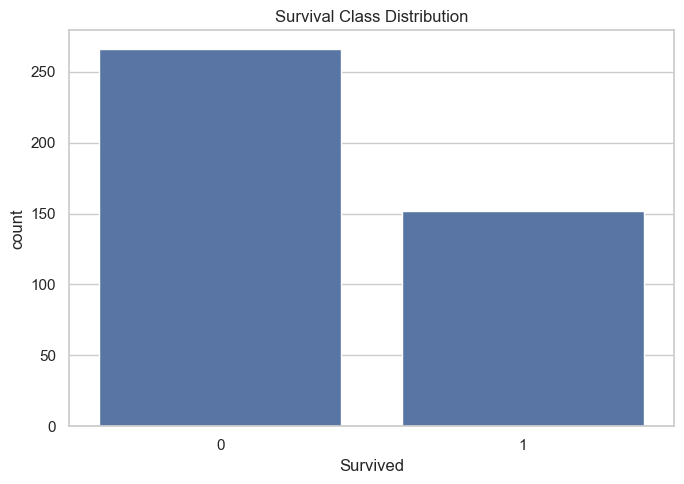

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=prepared, x=TARGET)
plt.title("Survival Class Distribution")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "survival_distribution.png", dpi=160)
plt.show()

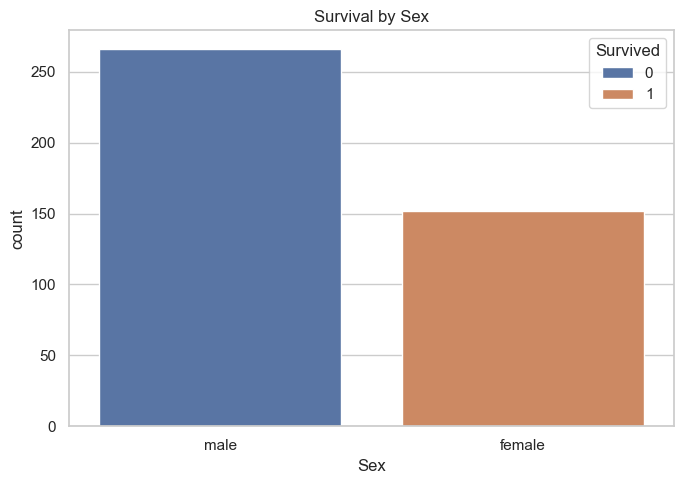

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=prepared, x="Sex", hue=TARGET)
plt.title("Survival by Sex")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "survival_by_sex.png", dpi=160)
plt.show()

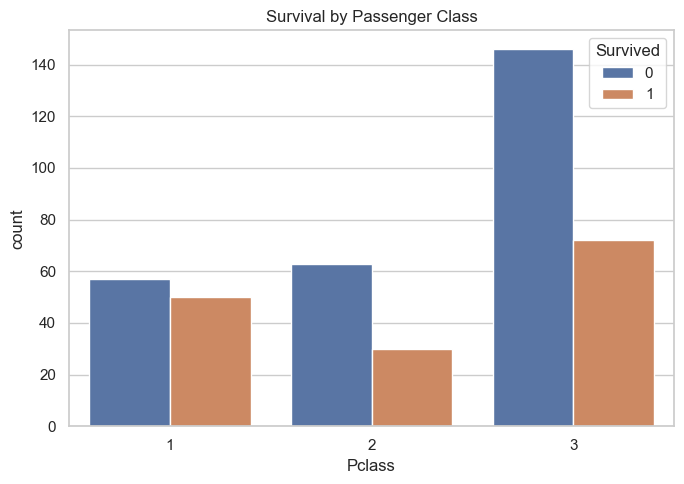

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=prepared, x="Pclass", hue=TARGET)
plt.title("Survival by Passenger Class")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "survival_by_pclass.png", dpi=160)
plt.show()

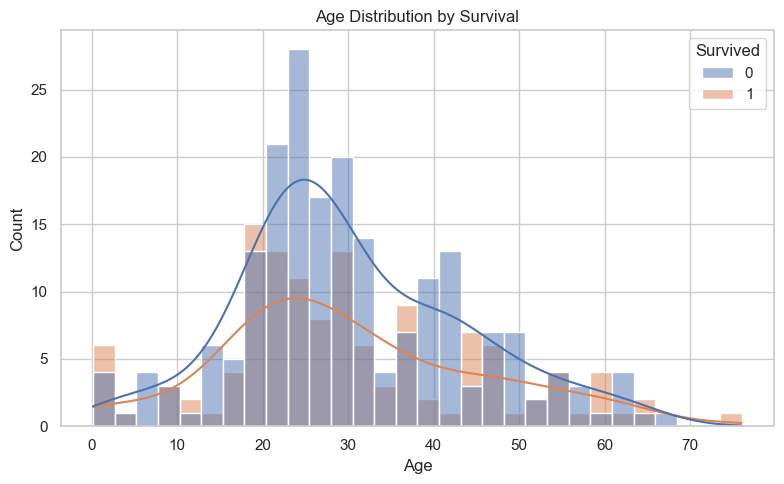

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=prepared, x="Age", hue=TARGET, bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_by_survival.png", dpi=160)
plt.show()

## Preprocessing

In [11]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Survived"]
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title", "CabinPresent"]

X = prepared.drop(columns=drop_columns)
y = prepared[TARGET]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

## Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_train.shape, X_test.shape

((334, 11), (84, 11))

## Train And Compare Models

In [13]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=6,
                    random_state=42,
                    class_weight="balanced",
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
}

results = []
fitted_models = {}
predictions_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, predictions),
            "precision": precision_score(y_test, predictions, zero_division=0),
            "recall": recall_score(y_test, predictions, zero_division=0),
            "f1": f1_score(y_test, predictions, zero_division=0),
        }
    )
    fitted_models[name] = model
    predictions_by_model[name] = predictions

results_df = pd.DataFrame(results).sort_values(
    by=["f1", "accuracy", "precision", "recall"],
    ascending=False,
)
results_df.to_csv(ARTIFACTS_DIR / "model_comparison.csv", index=False)
results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0


## Final Metrics

In [14]:
best_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_name]
best_predictions = predictions_by_model[best_name]

print("Best model:", best_name)
print(classification_report(y_test, best_predictions, zero_division=0))

Best model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



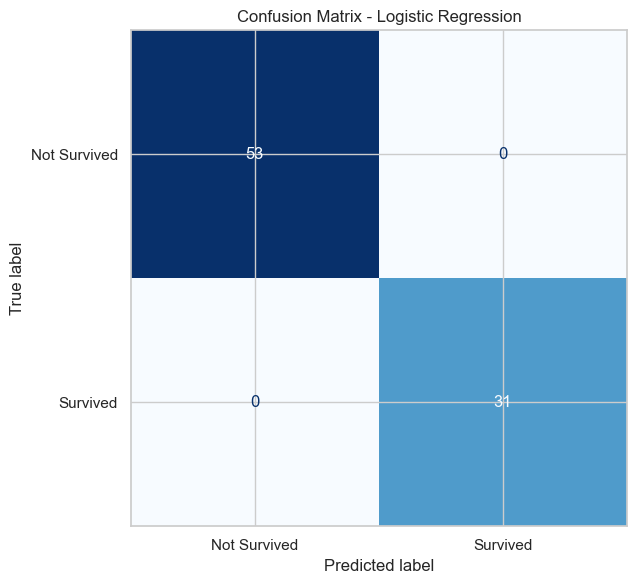

In [15]:
cm = confusion_matrix(y_test, best_predictions, labels=[0, 1])
display = ConfusionMatrixDisplay(cm, display_labels=["Not Survived", "Survived"])
fig, ax = plt.subplots(figsize=(7, 6))
display.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=160)
plt.show()

## Model Explanation With Feature Importance

In [16]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
estimator = best_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
else:
    importance_values = abs(estimator.coef_[0])

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(15)
)
importance_df.to_csv(ARTIFACTS_DIR / "feature_importance.csv", index=False)
importance_df

,feature,importance
8,categorical__Sex_male,2.621199
7,categorical__Sex_female,2.611045
14,categorical__Title_Mr,1.860955
13,categorical__Title_Miss,1.354445
15,categorical__Title_Mrs,1.186234
12,categorical__Title_Master,0.493634
16,categorical__Title_Rare,0.196243
10,categorical__Embarked_Q,0.140864
6,numeric__IsAlone,0.136228
11,categorical__Embarked_S,0.102080


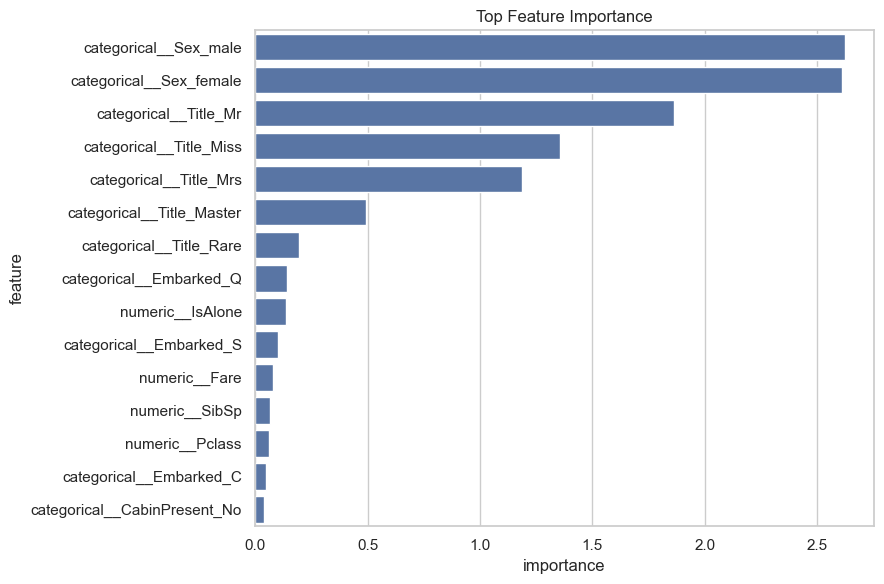

In [17]:
plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Top Feature Importance")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "feature_importance.png", dpi=160)
plt.show()

## Save Model

In [18]:
joblib.dump(best_model, MODEL_PATH)
MODEL_PATH

WindowsPath('artifacts/best_titanic_model.joblib')

## Interface Example

In [19]:
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame(
    [
        {
            "Pclass": 3,
            "Sex": "male",
            "Age": 28.0,
            "SibSp": 0,
            "Parch": 0,
            "Fare": 7.8958,
            "Embarked": "S",
            "Title": "Mr",
            "FamilySize": 1,
            "IsAlone": 1,
            "CabinPresent": "No",
        }
    ]
)

prediction = loaded_model.predict(sample)[0]
label = "Survived" if prediction == 1 else "Not survived"
print(label)

Not survived
